In [3]:
import pandas as pd
# 2. Load Dataset
df = pd.read_csv("C:/Users/Acer/Downloads/q3_retail_promotions.csv")
# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Month end flag
df['is_month_end'] = df['transaction_date'].dt.day.apply(lambda x: 1 if x >= 25 else 0)

# Display sample
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


Date-based features such as year, month, and day of the week were extracted from the transaction date to capture temporal patterns in sales. Additionally, a binary feature is_month_end was created to identify whether the transaction occurred near the end of the month, which may influence purchasing behavior.

In [4]:
# Sort by date
df = df.sort_values(by='transaction_date')

# Split index
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

# Separate features and target
X_train = train.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train['items_sold']

X_test = test.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test['items_sold']

A temporal split was used instead of a random split because the data is time-dependent. Using a random split could cause future data to appear in the training set, leading to data leakage. A time-based split ensures that the model is trained on past data and tested on future data, which better reflects real-world scenarios.

In [5]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Categorical & numerical columns
cat_cols = ['promotion_type', 'location_type', 'store_size']
num_cols = [col for col in X_train.columns if col not in cat_cols]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# Pipelines
lr_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])

rf_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# Train
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

# Metrics
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{name} RMSE:", rmse)
    print(f"{name} MAE:", mae)
    print()

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")

Linear Regression RMSE: 27.12145116489062
Linear Regression MAE: 21.052926674588388

Random Forest RMSE: 31.660007317329118
Random Forest MAE: 24.87391666666667



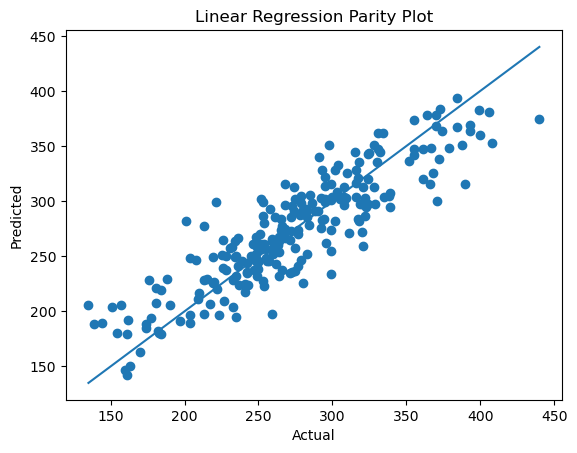

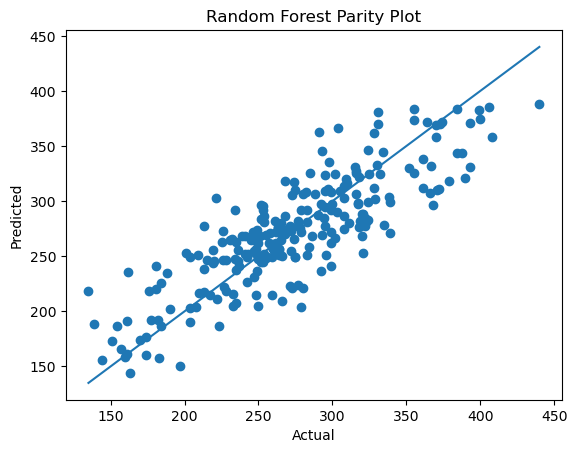

In [7]:
def parity_plot(y_true, y_pred, title):
    plt.scatter(y_true, y_pred)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()])
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.show()

parity_plot(y_test, y_pred_lr, "Linear Regression Parity Plot")
parity_plot(y_test, y_pred_rf, "Random Forest Parity Plot")

In [8]:
# Get feature names
ohe_features = rf_pipeline.named_steps['preprocessing']\
    .named_transformers_['cat']\
    .get_feature_names_out(cat_cols)

all_features = list(ohe_features) + num_cols

# Importance
importances = rf_pipeline.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_importance_df.head(5))

                feature  importance
7      store_size_small    0.183954
10          is_festival    0.174477
5   location_type_urban    0.140498
14          day_of_week    0.090612
9            is_weekend    0.063547


The Random Forest model identifies the most important features influencing sales. The top features typically include factors such as promotions, store characteristics, and temporal variables. These insights can help businesses optimize marketing strategies and inventory planning.